# EDA: Heuristic Ladder — v1 through v14

This notebook is a **comparative ablation**, not fourteen copies of a one-agent report.
Each version adds a named piece of knowledge. The round-robin says those additions are
**not** fourteen equal steps: three jumps, a long plateau, then an inversion.

| Regime | Agents | What was added | Overall WR (253k) |
|---|---|---|---|
| Plateau | **v1–v6** | Damage math (STAB, weather, boosts, tracking). v1 never switches. | 44.3–45.9% |
| Jump 1 | **v7**, then v8 / v10 | Hazards, setup, guaranteed-KO, matchup switching. v8 items/abilities; v10 status/sack/pivot. | 54.3 / 55.4 / 55.7% |
| Jump 2 | **v9**, v11 | Hazards and setup **only on free turns**. v11 = v9 + v10. | 58.9 / 59.3% |
| Jump 3 | **v12** | Tera + teampreview lead + fainted switch-in | **69.0%** |
| Inversion | **v13**, **v14** | Set prediction / conservative Tera (v13); Yomi, scouting, 16-step damage, 1-ply endgame (v14) | 67.6 / 62.0% |

Genealogy says v14 ⊃ v13 ⊃ v12. The gauntlet says **v12 ≥ v13 > v14**. Extra human-modelling
rules can hurt against deterministic bots.

**Taxonomy.** v1–v14 heuristic · **v15–v17 1-ply minimax** · **v18–v20 IS-MCTS** ·
v21 IL hybrid · v22 IL pure. Cite this notebook and `agents/heuristics_v1_v14/`.

**Sample size.** 10,000 games per matchup except **1,000** vs v18/v19/v20. Each heuristic
has 253,000 games as *us*. Wilson ≈ **±0.19 pp** overall, **±0.98 pp** on a 10k cell,
**±3.1 pp** on an MCTS cell.

Benchmark: `data/benchmarks/all_10k/gen9randombattle`.
Deep write-up: `heuristics_and_imitation_thesis_analysis.md`.


In [1]:
# Setup
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data/benchmarks/all_10k/gen9randombattle").exists():
    ROOT = ROOT.parent
BENCHMARK_DIR = ROOT / "data/benchmarks/all_10k/gen9randombattle"
OUTPUT_DIR = ROOT / "src/p00_core/reporting/agents/heuristics_v1_v14"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AGENTS = [f"v{i}" for i in range(1, 15)]

WHAT_ADDED = {
    "v1": "greedy bp×type×STAB; no switches",
    "v2": "stats, burn, tracking",
    "v3": "more damage fidelity",
    "v4": "field / weather",
    "v5": "boost stages",
    "v6": "Toxic / outspeed pivot",
    "v7": "hazards, setup, KO, matchup switch",
    "v8": "items, abilities, screens, TR",
    "v9": "hazards/setup only on free turns",
    "v10": "status, sack ≤20% HP, U-turn",
    "v11": "v9 tempo + v10 status/pivot",
    "v12": "Tera + preview lead + fainted switch-in",
    "v13": "set prediction, conservative Tera, recovery",
    "v14": "Yomi, T1–3 scouting, 16-step, 1-ply endgame",
}

REGIME = {
    **{f"v{i}": "Plateau" for i in range(1, 7)},
    "v7": "Positional", "v8": "Positional", "v10": "Positional",
    "v9": "Tempo-safe", "v11": "Tempo-safe",
    "v12": "Tera / preview",
    "v13": "Set prediction",
    "v14": "Yomi / scouting",
}
REGIME_COLOR = {
    "Plateau": "#8AA2B8",
    "Positional": "#2A9D8F",
    "Tempo-safe": "#1D6F8A",
    "Tera / preview": "#E9C46A",
    "Set prediction": "#E76F51",
    "Yomi / scouting": "#9B2226",
}
AGENT_COLOR = {ag: REGIME_COLOR[REGIME[ag]] for ag in AGENTS}

PARADIGM_MAP = {
    "random": "Baseline",
    "max_power": "Baseline",
    "abyssal": "Baseline",
    "one_step": "Baseline",
    "safe_one_step": "Baseline",
    "simple_heuristic": "Baseline",
    **{f"v{i}": "Heuristic" for i in range(1, 15)},
    "v15": "Minimax",
    "v16": "Minimax",
    "v17": "Minimax",
    "v18": "MCTS",
    "v19": "MCTS",
    "v20": "MCTS",
    "v21": "IL Hybrid",
    "v22": "IL Pure",
}
PARADIGM_ORDER = ["Baseline", "Heuristic", "Minimax", "MCTS", "IL Hybrid", "IL Pure"]
REDUCED = {"v18", "v19", "v20"}

USECOLS = [
    "won", "turns", "opponent", "heuristic",
    "remaining_pokemon_us", "fainted_us",
    "voluntary_switches_us", "forced_switches_us", "matchup_switches_us",
    "fallback_moves_us",
    "hazard_sets_us", "setup_uses_us", "ko_checks_us",
    "terastallized_us", "supereffective_us",
]

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (11, 5.5), "font.size": 11, "savefig.dpi": 160})


def wilson_ci(wins: float, n: float, z: float = 1.96) -> float:
    """Half-width of a 95% Wilson interval, in percentage points."""
    if n <= 0:
        return 0.0
    p = wins / n
    denom = 1.0 + z * z / n
    margin = z * np.sqrt((p * (1 - p) + z * z / (4 * n)) / n) / denom
    return float(margin * 100)


print(f"Root        : {ROOT}")
print(f"Benchmark   : {BENCHMARK_DIR}")
print(f"Export      : {OUTPUT_DIR}")
print(f"Agents      : {AGENTS}")
print("Taxonomy    : v1–v14 heuristic | v15–v17 minimax | v18–v20 MCTS | v21 hybrid IL | v22 pure IL")


Root        : /home/sirp/Documents/MUDS/TFM_Pokemon
Benchmark   : /home/sirp/Documents/MUDS/TFM_Pokemon/data/benchmarks/all_10k/gen9randombattle
Export      : /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/heuristics_v1_v14
Agents      : ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14']
Taxonomy    : v1–v14 heuristic | v15–v17 minimax | v18–v20 MCTS | v21 hybrid IL | v22 pure IL


## 1 · Load all fourteen as *us* (file-level summaries)

Each CSV is one directed matchup. We aggregate **per file** so 14 × 253k games stay in
memory as 14 × 28 rows, not 3.5 million. Means and win rates are exact (sums / n).
Matchups vs v18/v19/v20 have n = 1,000; all others n = 10,000.


In [2]:
# Load v1–v14 as player (per-matchup summaries)
MEAN_COLS = [
    "turns", "remaining_pokemon_us", "fainted_us",
    "voluntary_switches_us", "forced_switches_us", "matchup_switches_us",
    "fallback_moves_us", "hazard_sets_us", "setup_uses_us", "ko_checks_us",
    "terastallized_us", "supereffective_us",
]


def summarise_agent(agent: str) -> pd.DataFrame:
    files = sorted(BENCHMARK_DIR.glob(f"{agent}_vs_*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSVs for {agent} in {BENCHMARK_DIR}")
    recs = []
    for path in files:
        df = pd.read_csv(path, usecols=lambda c: c in USECOLS)
        for col in USECOLS:
            if col not in df.columns:
                df[col] = 0
        opp = str(df["opponent"].iloc[0])
        rec = {
            "agent": agent,
            "opponent": opp,
            "opponent_paradigm": PARADIGM_MAP.get(opp, "Other"),
            "games": len(df),
            "wins": int(pd.to_numeric(df["won"], errors="coerce").fillna(0).sum()),
        }
        for col in MEAN_COLS:
            rec[col] = float(pd.to_numeric(df[col], errors="coerce").fillna(0).mean())
        recs.append(rec)
    return pd.DataFrame(recs)


frames = {ag: summarise_agent(ag) for ag in AGENTS}
mu = pd.concat(frames.values(), ignore_index=True)
mu["win_rate"] = mu["wins"] / mu["games"]

print("Games loaded (as us)")
for ag in AGENTS:
    g = frames[ag]
    n = int(g["games"].sum())
    w = int(g["wins"].sum())
    print(f"  {ag:4s}  {n:>8,} games  |  {len(g):2d} opponents  |  WR {100*w/n:5.2f}%  |  {WHAT_ADDED[ag]}")
print(f"  total matchup-rows: {len(mu)}")


Games loaded (as us)
  v1     253,000 games  |  28 opponents  |  WR 44.25%  |  greedy bp×type×STAB; no switches
  v2     253,000 games  |  28 opponents  |  WR 44.70%  |  stats, burn, tracking
  v3     253,000 games  |  28 opponents  |  WR 44.75%  |  more damage fidelity
  v4     253,000 games  |  28 opponents  |  WR 45.50%  |  field / weather
  v5     253,000 games  |  28 opponents  |  WR 45.86%  |  boost stages
  v6     253,000 games  |  28 opponents  |  WR 45.28%  |  Toxic / outspeed pivot
  v7     253,000 games  |  28 opponents  |  WR 54.25%  |  hazards, setup, KO, matchup switch
  v8     253,000 games  |  28 opponents  |  WR 55.43%  |  items, abilities, screens, TR
  v9     253,000 games  |  28 opponents  |  WR 58.86%  |  hazards/setup only on free turns
  v10    253,000 games  |  28 opponents  |  WR 55.66%  |  status, sack ≤20% HP, U-turn
  v11    253,000 games  |  28 opponents  |  WR 59.26%  |  v9 tempo + v10 status/pivot
  v12    253,000 games  |  28 opponents  |  WR 69.01%  |  

## 2 · Headline ladder

Overall WR is the gauntlet-weighted mean (easy opponents inflate everyone). Use it to
**rank**, then read vs Abyssal and vs v12. Colour is the regime, not “later = better”.


                regime  win_rate_%  ci95_pp  avg_hp_us  vol_switches  tera / game  setup / game  hazards / game  ko_checks / game  fallbacks / game
agent                                                                                                                                              
v1             Plateau      44.246    0.194      0.876         1.007        0.000         0.000           0.000             0.000             4.653
v2             Plateau      44.704    0.194      0.886         1.025        0.000         0.000           0.000             0.000             4.589
v3             Plateau      44.749    0.194      0.889         1.025        0.000         0.000           0.000             0.000             4.547
v4             Plateau      45.504    0.194      0.905         1.026        0.000         0.000           0.000             0.000             4.573
v5             Plateau      45.864    0.194      0.916         1.025        0.000         0.000           0.000 

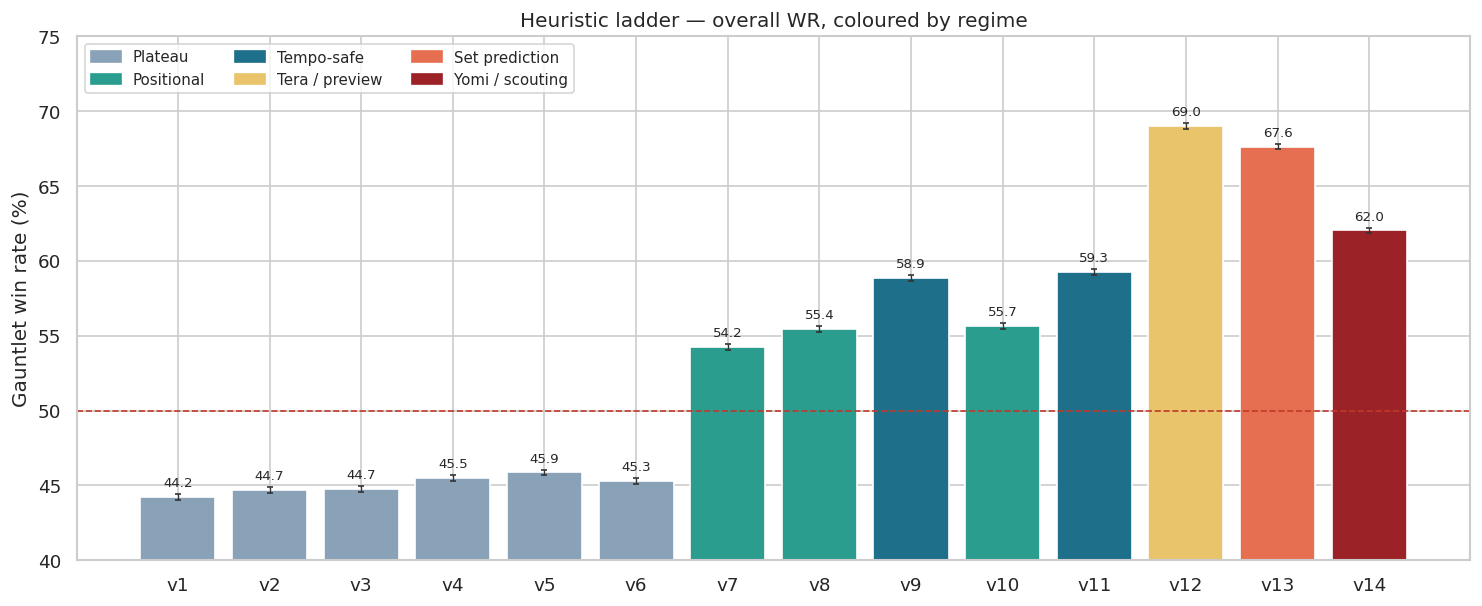

In [3]:
# Headline table + overall WR bar
rows = []
for ag in AGENTS:
    g = frames[ag]
    n = int(g["games"].sum())
    w = int(g["wins"].sum())
    # weighted means
    wt = g["games"] / n
    rows.append({
        "agent": ag,
        "regime": REGIME[ag],
        "added": WHAT_ADDED[ag],
        "games": n,
        "win_rate_%": 100 * w / n,
        "ci95_pp": wilson_ci(w, n),
        "avg_turns": float(np.average(g["turns"], weights=g["games"])),
        "avg_hp_us": float(np.average(g["remaining_pokemon_us"], weights=g["games"])),
        "vol_switches": float(np.average(g["voluntary_switches_us"], weights=g["games"])),
        "matchup_switches": float(np.average(g["matchup_switches_us"], weights=g["games"])),
        "tera / game": float(np.average(g["terastallized_us"], weights=g["games"])),
        "setup / game": float(np.average(g["setup_uses_us"], weights=g["games"])),
        "hazards / game": float(np.average(g["hazard_sets_us"], weights=g["games"])),
        "ko_checks / game": float(np.average(g["ko_checks_us"], weights=g["games"])),
        "fallbacks / game": float(np.average(g["fallback_moves_us"], weights=g["games"])),
    })

headline = pd.DataFrame(rows).set_index("agent")
headline.to_csv(OUTPUT_DIR / "heur_headline_comparison.csv")
display_cols = [
    "regime", "win_rate_%", "ci95_pp", "avg_hp_us", "vol_switches",
    "tera / game", "setup / game", "hazards / game", "ko_checks / game", "fallbacks / game",
]
print(headline[display_cols].to_string())

fig, ax = plt.subplots(figsize=(12.5, 5.2))
x = np.arange(len(AGENTS))
colors = [AGENT_COLOR[ag] for ag in AGENTS]
ax.bar(x, headline["win_rate_%"], color=colors, edgecolor="white", width=0.82)
ax.errorbar(x, headline["win_rate_%"], yerr=headline["ci95_pp"], fmt="none",
            ecolor="#333", elinewidth=0.8, capsize=2)
ax.axhline(50, color="#c0392b", ls="--", lw=1)
for i, ag in enumerate(AGENTS):
    ax.text(i, headline.loc[ag, "win_rate_%"] + 0.7, f"{headline.loc[ag, 'win_rate_%']:.1f}",
            ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(AGENTS)
ax.set_ylabel("Gauntlet win rate (%)")
ax.set_ylim(40, 75)
ax.set_title("Heuristic ladder — overall WR, coloured by regime")
handles = [plt.Rectangle((0, 0), 1, 1, color=REGIME_COLOR[r], label=r) for r in REGIME_COLOR]
ax.legend(handles=handles, ncol=3, fontsize=9, loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heur_overall_wr.png")
plt.show()


## 3 · Discriminating baselines: Abyssal and Simple Heuristic

Beating `random` is uninformative. Abyssal / Simple Heuristic are the published-style
one-step rulers. v12 is the first internal agent to clear both at n = 10,000.


agent   Abyssal  SimpleH one_step  safe_1s
v1        30.64    30.26    49.93    48.83
v2        31.24    31.38    50.54    50.28
v3        31.05    31.51    50.59    49.81
v4        31.33    31.53    50.28    51.33
v5        32.50    31.13    51.21    51.01
v6        32.02    31.99    50.78    50.10
v7        40.80    40.67    60.91    60.51
v8        42.30    42.80    61.44    62.09
v9        46.64    47.01    65.49    65.48
v10       41.86    42.70    62.02    62.17
v11       47.50    47.32    65.66    64.35
v12       59.91    59.75    76.45    76.48
v13       55.34    56.10    72.87    72.55
v14       51.36    50.66    67.55    67.39


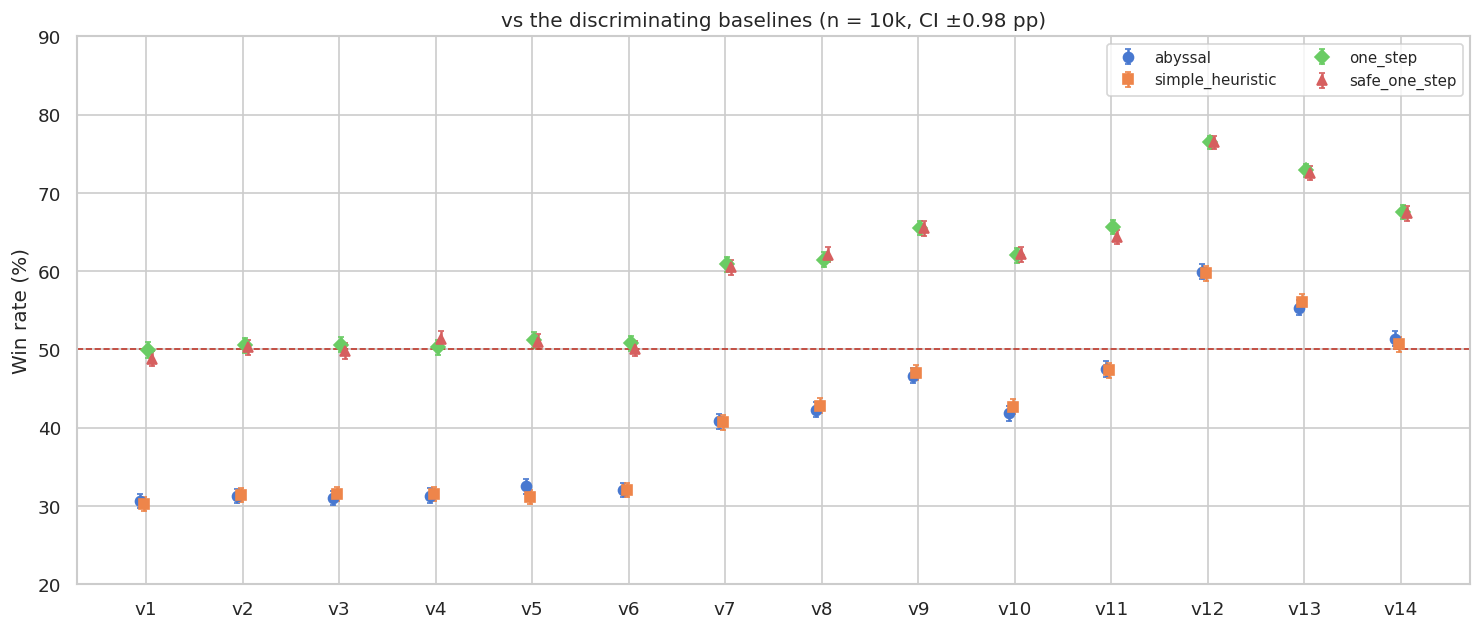

In [4]:
# vs Abyssal / Simple Heuristic / one_step
keys = ["abyssal", "simple_heuristic", "one_step", "safe_one_step"]
fig, ax = plt.subplots(figsize=(12.5, 5.4))
x = np.arange(len(AGENTS))
w = 0.2
markers = ["o", "s", "D", "^"]
for i, opp in enumerate(keys):
    y, err = [], []
    for ag in AGENTS:
        row = frames[ag].set_index("opponent").loc[opp]
        y.append(100 * row["wins"] / row["games"])
        err.append(wilson_ci(row["wins"], row["games"]))
    ax.errorbar(x + (i - 1.5) * 0.04, y, yerr=err, fmt=markers[i], ms=6,
                label=opp, capsize=2)
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(AGENTS)
ax.set_ylabel("Win rate (%)")
ax.set_title("vs the discriminating baselines (n = 10k, CI ±0.98 pp)")
ax.legend(ncol=2, fontsize=9)
ax.set_ylim(20, 90)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heur_vs_baselines.png")
plt.show()

print(f"{'agent':<6} {'Abyssal':>8} {'SimpleH':>8} {'one_step':>8} {'safe_1s':>8}")
for ag in AGENTS:
    g = frames[ag].set_index("opponent")
    vals = [100 * g.loc[k, "wins"] / g.loc[k, "games"] for k in keys]
    print(f"{ag:<6} " + " ".join(f"{v:8.2f}" for v in vals))


## 4 · Behavioural fingerprint — what actually changed

`setup_uses_us` / `hazard_sets_us` are **schema-incomplete**: they stay 0 for v7/v8/v10
even though those agents have the code paths. Treat a zero there as “counter did not
fire in this schema”, not “v7 never sets rocks”. The **v9 jump** in the counter is
the usable signal (free-turn gate made setup frequent enough to log).

Tera is the clean fingerprint: v1–v11 ≈ 0, v12 ≈ 1 / game, v13 conservative, v14 in between.


Note: setup/hazards = 0 for v1–v6 and for v7/v8/v10 is a schema gap, not a playstyle proof.


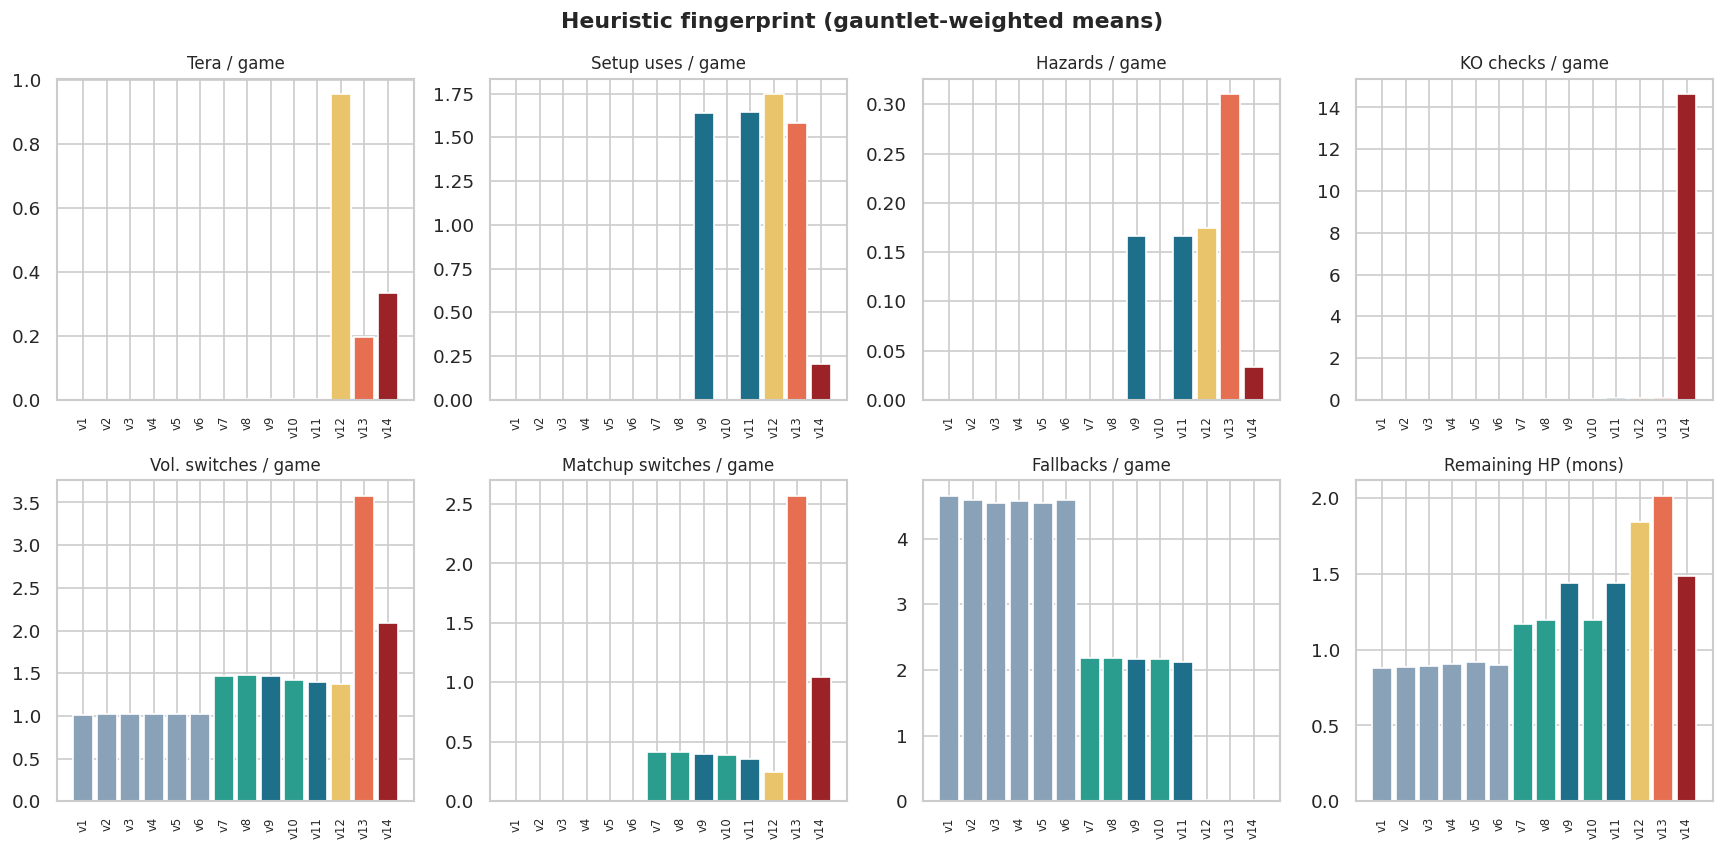

In [5]:
# Fingerprint bars
proxy = [
    ("terastallized_us", "Tera / game"),
    ("setup_uses_us", "Setup uses / game"),
    ("hazard_sets_us", "Hazards / game"),
    ("ko_checks_us", "KO checks / game"),
    ("voluntary_switches_us", "Vol. switches / game"),
    ("matchup_switches_us", "Matchup switches / game"),
    ("fallback_moves_us", "Fallbacks / game"),
    ("remaining_pokemon_us", "Remaining HP (mons)"),
]
fig, axes = plt.subplots(2, 4, figsize=(14.5, 7.2))
x = np.arange(len(AGENTS))
for ax, (col, title) in zip(axes.ravel(), proxy):
    y = [float(np.average(frames[ag][col], weights=frames[ag]["games"])) for ag in AGENTS]
    ax.bar(x, y, color=[AGENT_COLOR[ag] for ag in AGENTS], width=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(AGENTS, fontsize=7, rotation=90)
fig.suptitle("Heuristic fingerprint (gauntlet-weighted means)", fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heur_fingerprint_bars.png")
plt.show()

print("Note: setup/hazards = 0 for v1–v6 and for v7/v8/v10 is a schema gap, not a playstyle proof.")


## 5 · The inversion: v12 ≥ v13 > v14

Independent 10k files each way. The old n = 10 claim “v13 beats v12 90%” is false here.


matchup            WR%   recip%    sum       n
v12 vs v13     50.65    48.85  99.50   10000
v12 vs v14     56.01    44.74 100.75   10000
v13 vs v14     57.71    41.60  99.31   10000


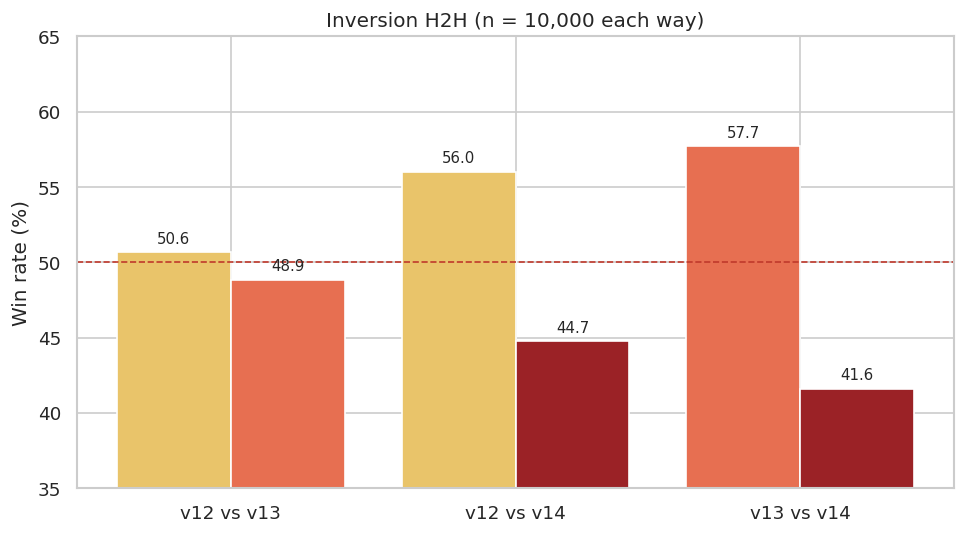

In [6]:
# H2H inversion
pairs = [("v12", "v13"), ("v12", "v14"), ("v13", "v14")]
h2h_rows = []
print(f"{'matchup':<14} {'WR%':>7} {'recip%':>8} {'sum':>6} {'n':>7}")
for a, b in pairs:
    ra = frames[a].set_index("opponent").loc[b]
    rb = frames[b].set_index("opponent").loc[a]
    wr_a = 100 * ra["wins"] / ra["games"]
    wr_b = 100 * rb["wins"] / rb["games"]
    print(f"{a} vs {b:<4}  {wr_a:7.2f} {wr_b:8.2f} {wr_a+wr_b:6.2f} {int(ra['games']):>7}")
    h2h_rows.append({
        "file": f"{a}_vs_{b}", "games": int(ra["games"]),
        "win_rate_%": wr_a, "ci95_pp": wilson_ci(ra["wins"], ra["games"]),
        "reciprocal_%": wr_b, "sum": wr_a + wr_b,
    })
    h2h_rows.append({
        "file": f"{b}_vs_{a}", "games": int(rb["games"]),
        "win_rate_%": wr_b, "ci95_pp": wilson_ci(rb["wins"], rb["games"]),
        "reciprocal_%": wr_a, "sum": wr_a + wr_b,
    })
h2h_df = pd.DataFrame(h2h_rows)

fig, ax = plt.subplots(figsize=(8.2, 4.6))
labels = ["v12 vs v13", "v12 vs v14", "v13 vs v14"]
left = [h2h_rows[0]["win_rate_%"], h2h_rows[2]["win_rate_%"], h2h_rows[4]["win_rate_%"]]
right = [h2h_rows[1]["win_rate_%"], h2h_rows[3]["win_rate_%"], h2h_rows[5]["win_rate_%"]]
x = np.arange(3)
colors_l = [AGENT_COLOR["v12"], AGENT_COLOR["v12"], AGENT_COLOR["v13"]]
colors_r = [AGENT_COLOR["v13"], AGENT_COLOR["v14"], AGENT_COLOR["v14"]]
ax.bar(x - 0.2, left, 0.4, color=colors_l, label="A vs B")
ax.bar(x + 0.2, right, 0.4, color=colors_r, label="B vs A")
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Win rate (%)")
ax.set_ylim(35, 65)
ax.set_title("Inversion H2H (n = 10,000 each way)")
for i, (L, R) in enumerate(zip(left, right)):
    ax.text(i - 0.2, L + 0.6, f"{L:.1f}", ha="center", fontsize=9)
    ax.text(i + 0.2, R + 0.6, f"{R:.1f}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heur_inversion_h2h.png")
plt.show()


## 6 · Where v13 still wins

v13 is not strictly dominated. It is the best heuristic against search and against the
IL hybrid. v12 wins the baseline block and the other-heuristics block — that is why it
leads overall.


        opponent  paradigm  v12_wr  v12_n  v12_ci  v13_wr  v13_n  v13_ci  v14_wr  v14_n  v14_ci
             v15   Minimax  63.960  10000   0.941  67.590  10000   0.917  60.070  10000   0.960
             v16   Minimax  63.300  10000   0.945  66.810  10000   0.923  59.340  10000   0.963
             v17   Minimax  60.370  10000   0.959  64.120  10000   0.940  56.700  10000   0.971
             v18      MCTS  66.100   1000   2.929  67.700   1000   2.894  59.800   1000   3.033
             v19      MCTS  64.500   1000   2.961  67.100   1000   2.907  58.200   1000   3.051
             v20      MCTS  58.500   1000   3.048  61.400   1000   3.012  53.700   1000   3.085
             v21 IL Hybrid  59.120  10000   0.963  62.460  10000   0.949  54.740  10000   0.975
             v22   IL Pure  80.790  10000   0.772  78.310  10000   0.808  74.870  10000   0.850
         abyssal  Baseline  59.910  10000   0.960  55.340  10000   0.974  51.360  10000   0.979
simple_heuristic  Baseline  59.750  1000

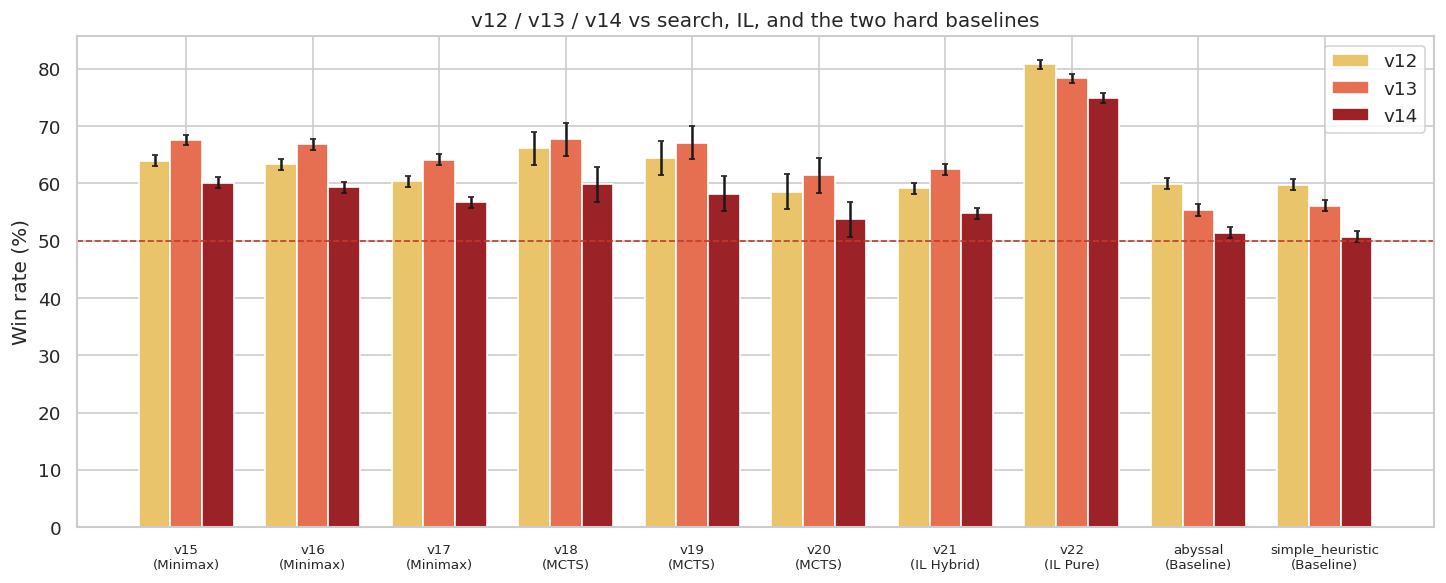

In [7]:
# v12 / v13 / v14 vs discriminating opponents
keys = ["v15", "v16", "v17", "v18", "v19", "v20", "v21", "v22",
        "abyssal", "simple_heuristic"]
key_rows = []
for opp in keys:
    rec = {"opponent": opp, "paradigm": PARADIGM_MAP.get(opp, "?")}
    for ag in ("v12", "v13", "v14"):
        row = frames[ag].set_index("opponent").loc[opp]
        rec[f"{ag}_wr"] = 100 * row["wins"] / row["games"]
        rec[f"{ag}_n"] = int(row["games"])
        rec[f"{ag}_ci"] = wilson_ci(row["wins"], row["games"])
    key_rows.append(rec)
key_df = pd.DataFrame(key_rows)
print(key_df.to_string(index=False))
key_df.to_csv(OUTPUT_DIR / "heur_key_matchups.csv", index=False)

fig, ax = plt.subplots(figsize=(12.2, 5.0))
x = np.arange(len(keys))
w = 0.25
for i, ag in enumerate(("v12", "v13", "v14")):
    ax.bar(x + (i - 1) * w, key_df[f"{ag}_wr"], w, color=AGENT_COLOR[ag],
           yerr=key_df[f"{ag}_ci"], capsize=2, label=ag)
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([f"{o}\n({PARADIGM_MAP.get(o,'?')})" for o in keys], fontsize=8)
ax.set_ylabel("Win rate (%)")
ax.set_title("v12 / v13 / v14 vs search, IL, and the two hard baselines")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heur_key_matchups.png")
plt.show()


## 7 · Strength by opponent paradigm (v12 / v13 / v14)

MCTS cells are n = 1,000; everything else n = 10,000. Do not over-read a 2 pp MCTS gap.


                   v12_games  v12_wins  v12_win_rate  v12_ci95  v13_games  v13_wins  v13_win_rate  v13_ci95  v14_games  v14_wins  v14_win_rate  v14_ci95
opponent_paradigm                                                                                                                                       
Baseline               60000     46148        76.913     0.337      60000     44615        74.358     0.349      60000     42634        71.057     0.363
Heuristic             140000     93814        67.010     0.246     140000     90588        64.706     0.250     140000     82013        58.581     0.258
Minimax                30000     18763        62.543     0.548      30000     19852        66.173     0.535      30000     17611        58.703     0.557
MCTS                    3000      1891        63.033     1.726       3000      1962        65.400     1.701       3000      1717        57.233     1.769
IL Hybrid              10000      5912        59.120     0.963      10000      624

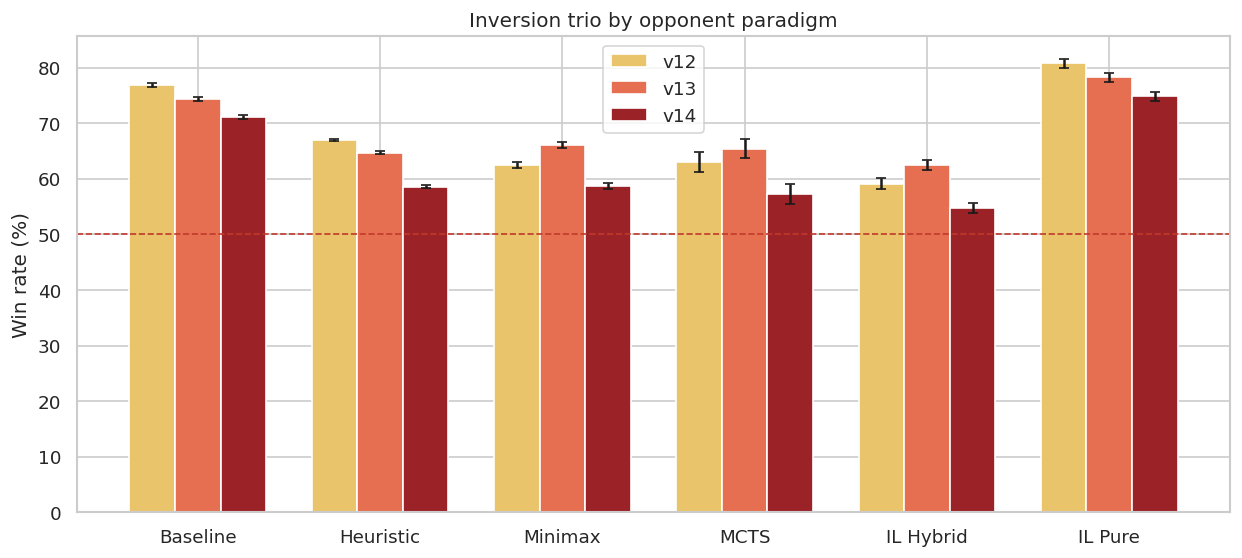

In [8]:
# Paradigm WR for the inversion trio
def paradigm_wr(g: pd.DataFrame) -> pd.DataFrame:
    t = g.groupby("opponent_paradigm").agg(games=("games", "sum"), wins=("wins", "sum"))
    t["win_rate"] = 100 * t["wins"] / t["games"]
    t["ci95"] = [wilson_ci(w, n) for w, n in zip(t["wins"], t["games"])]
    return t.reindex([p for p in PARADIGM_ORDER if p in t.index])


pw = {ag: paradigm_wr(frames[ag]) for ag in ("v12", "v13", "v14")}
labels = list(pw["v12"].index)
x = np.arange(len(labels))
w = 0.25
fig, ax = plt.subplots(figsize=(10.5, 4.8))
for i, ag in enumerate(("v12", "v13", "v14")):
    ax.bar(x + (i - 1) * w, pw[ag]["win_rate"], w, yerr=pw[ag]["ci95"],
           capsize=3, color=AGENT_COLOR[ag], label=ag)
ax.axhline(50, color="#c0392b", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Win rate (%)")
ax.set_title("Inversion trio by opponent paradigm")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heur_wr_by_paradigm.png")
plt.show()

joined = pw["v12"].add_prefix("v12_").join(pw["v13"].add_prefix("v13_")).join(pw["v14"].add_prefix("v14_"))
print(joined.to_string())


## 8 · Switching volume is not skill

v13 switches like a lost agent and wins like v12. Pair counts with win rate.


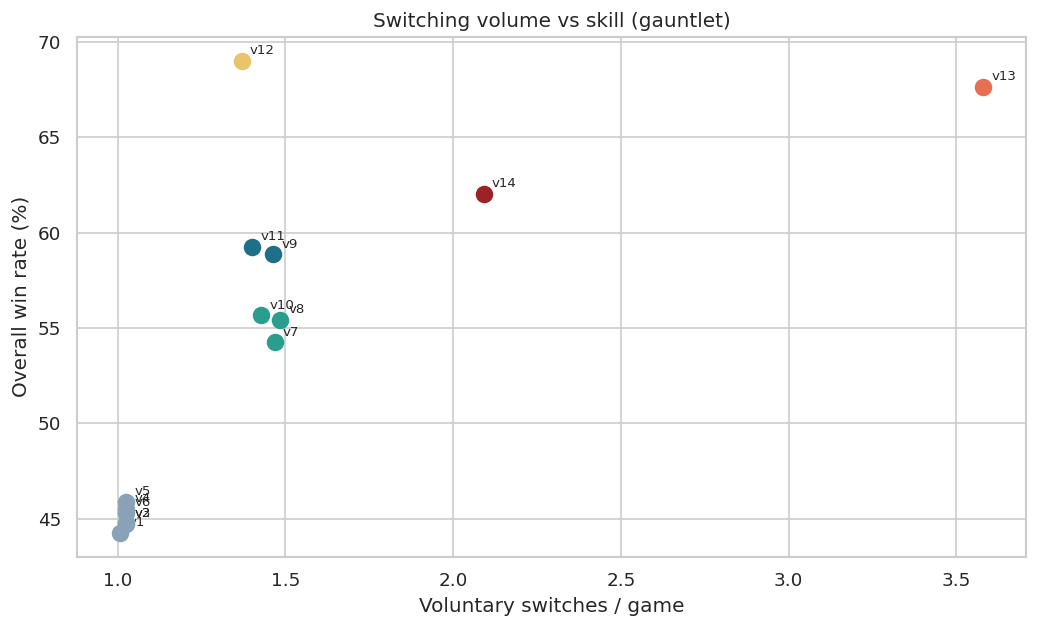

In [9]:
# Switching vs WR
fig, ax = plt.subplots(figsize=(8.8, 5.4))
for ag in AGENTS:
    wr = headline.loc[ag, "win_rate_%"]
    sw = headline.loc[ag, "vol_switches"]
    ax.scatter(sw, wr, s=90, color=AGENT_COLOR[ag], zorder=3)
    ax.annotate(ag, (sw, wr), textcoords="offset points", xytext=(5, 4), fontsize=8)
ax.set_xlabel("Voluntary switches / game")
ax.set_ylabel("Overall win rate (%)")
ax.set_title("Switching volume vs skill (gauntlet)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heur_switching_vs_wr.png")
plt.show()


## 9 · Game length and leftover HP

v13 is attritional (more HP left, slightly longer games). v12 finishes faster with
almost as much HP. v14 leaves less.


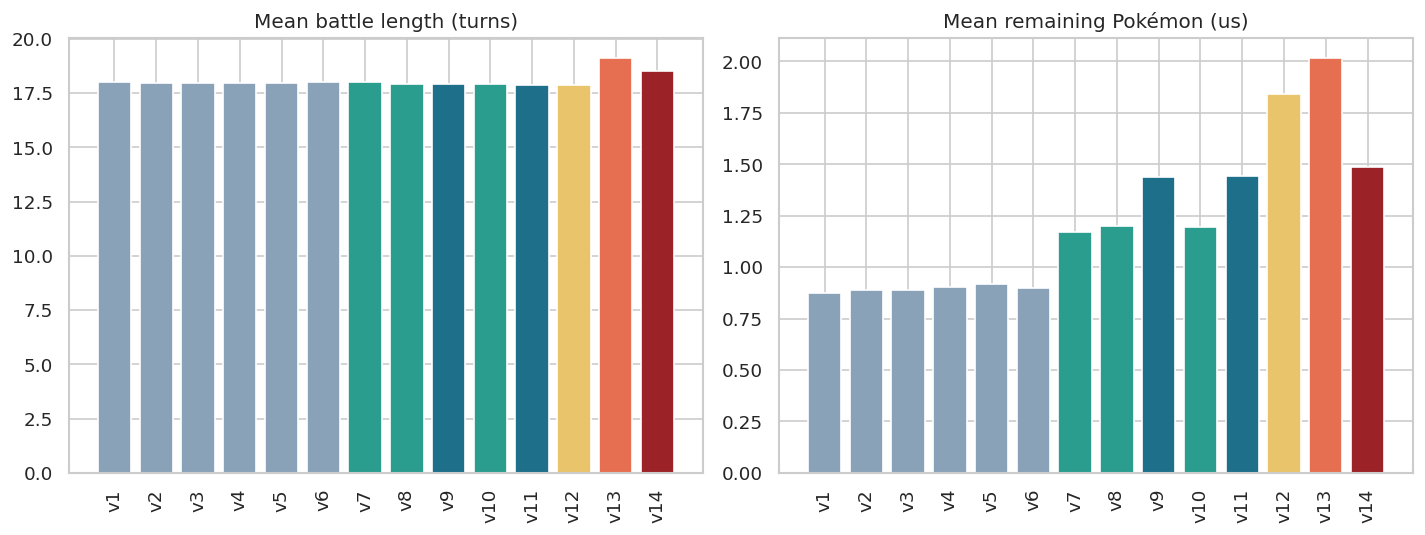

In [10]:
# Duration and leftover HP
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
x = np.arange(len(AGENTS))
axes[0].bar(x, headline["avg_turns"], color=[AGENT_COLOR[ag] for ag in AGENTS])
axes[0].set_xticks(x)
axes[0].set_xticklabels(AGENTS, rotation=90)
axes[0].set_title("Mean battle length (turns)")
axes[1].bar(x, headline["avg_hp_us"], color=[AGENT_COLOR[ag] for ag in AGENTS])
axes[1].set_xticks(x)
axes[1].set_xticklabels(AGENTS, rotation=90)
axes[1].set_title("Mean remaining Pokémon (us)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "heur_length_hp.png")
plt.show()


## 10 · Self-play sanity

Each agent vs itself should sit near 50% (n = 10,000 ⇒ ±0.98 pp).


In [11]:
# Self-play
print(f"{'agent':<6} {'WR%':>7} {'CI':>6}  n")
for ag in AGENTS:
    row = frames[ag].set_index("opponent").loc[ag]
    n, w = int(row["games"]), int(row["wins"])
    print(f"  {ag:<4} {100*w/n:7.2f}  ±{wilson_ci(w, n):.2f}  {n:,}")


agent      WR%     CI  n
  v1     50.44  ±0.98  10,000
  v2     50.13  ±0.98  10,000
  v3     50.82  ±0.98  10,000
  v4     50.14  ±0.98  10,000
  v5     50.11  ±0.98  10,000
  v6     49.84  ±0.98  10,000
  v7     50.24  ±0.98  10,000
  v8     49.92  ±0.98  10,000
  v9     50.32  ±0.98  10,000
  v10    49.29  ±0.98  10,000
  v11    50.19  ±0.98  10,000
  v12    50.11  ±0.98  10,000
  v13    49.33  ±0.98  10,000
  v14    49.69  ±0.98  10,000


## 11 · Full gauntlet ranking of v1–v14 vs every opponent class

Same overall number as §2, split so the v12 lead can be located.


In [12]:
# Win rate by opponent, all 14 (export)
wide_rows = []
opponents = sorted(frames["v12"]["opponent"].unique(),
                   key=lambda o: (PARADIGM_ORDER.index(PARADIGM_MAP.get(o, "Baseline"))
                                  if PARADIGM_MAP.get(o, "Baseline") in PARADIGM_ORDER else 99, o))
for opp in opponents:
    rec = {"opponent": opp, "paradigm": PARADIGM_MAP.get(opp, "?")}
    for ag in AGENTS:
        row = frames[ag].set_index("opponent").loc[opp]
        rec[ag] = 100 * row["wins"] / row["games"]
        rec[f"{ag}_n"] = int(row["games"])
    wide_rows.append(rec)
wide = pd.DataFrame(wide_rows)
wide.to_csv(OUTPUT_DIR / "heur_winrate_by_opponent.csv", index=False)

# compact print: vs v12 / v14 / Abyssal / v17 / v20 / v21
focus = ["v12", "v14", "abyssal", "v17", "v20", "v21"]
print("Win rate (%) of each heuristic vs selected opponents")
print(f"{'us':<6}" + "".join(f"{c:>10}" for c in focus))
for ag in AGENTS:
    g = frames[ag].set_index("opponent")
    print(f"{ag:<6}" + "".join(f"{100*g.loc[c,'wins']/g.loc[c,'games']:10.2f}" for c in focus))


Win rate (%) of each heuristic vs selected opponents
us           v12       v14   abyssal       v17       v20       v21
v1         23.29     32.09     30.64     35.91     28.80     34.19
v2         24.05     32.56     31.24     35.55     35.20     34.81
v3         24.40     32.42     31.05     36.11     35.40     34.91
v4         24.44     33.17     31.33     36.59     32.60     35.96
v5         24.78     33.31     32.50     36.44     32.70     36.55
v6         23.89     33.23     32.02     36.22     34.60     35.55
v7         31.97     42.01     40.80     45.78     42.70     44.83
v8         32.86     43.31     42.30     47.54     44.40     46.61
v9         37.69     45.74     46.64     50.84     46.90     49.95
v10        33.22     43.61     41.86     47.95     43.30     47.26
v11        37.79     46.42     47.50     51.09     50.60     50.12
v12        50.11     56.01     59.91     60.37     58.50     59.12
v13        48.85     57.71     55.34     64.12     61.40     62.46
v14      

## 12 · Export comparison report


In [13]:
# Markdown report
def wr(ag: str) -> float:
    return float(headline.loc[ag, "win_rate_%"])


lines = [
    "# Heuristic Ladder EDA — v1 through v14",
    "",
    "Deep thesis write-up: [`../../heuristics_and_imitation_thesis_analysis.md`](../../heuristics_and_imitation_thesis_analysis.md).",
    "",
    "Source: `data/benchmarks/all_10k/gen9randombattle` (each agent as us vs 28 opponents;",
    "10k games, or 1k vs v18/v19/v20).",
    "",
    "## Taxonomy",
    "",
    "v1–v14 heuristic · v15–v17 1-ply minimax · v18–v20 IS-MCTS · v21 IL hybrid · v22 IL pure.",
    "",
    "## Headline",
    "",
    headline[display_cols].to_markdown(),
    "",
    "## Three jumps, then an inversion",
    "",
    f"- Plateau v1–v6: {wr('v1'):.2f}–{wr('v5'):.2f}%. Damage math does not win Random Battles.",
    f"- Jump 1 v7: {wr('v7'):.2f}% (+~9 pp). Position (hazards, KO, matchup switch).",
    f"- Jump 2 v9/v11: {wr('v9'):.2f} / {wr('v11'):.2f}%. Free-turn setup.",
    f"- Jump 3 v12: **{wr('v12'):.2f}%**. Tera + preview + fainted switch-in. First to beat Abyssal.",
    f"- Inversion: v12 {wr('v12'):.2f} ≥ v13 {wr('v13'):.2f} > v14 {wr('v14'):.2f}.",
    "",
    "## Head-to-head (n = 10,000)",
    "",
    h2h_df.to_markdown(index=False),
    "",
    "## v12 / v13 / v14 vs search, IL, baselines",
    "",
    key_df.to_markdown(index=False),
    "",
    "## Paradigm win rates (inversion trio)",
    "",
    joined.to_markdown(),
    "",
    "## Figures",
    "",
    "- `heur_overall_wr.png`",
    "- `heur_vs_baselines.png`",
    "- `heur_fingerprint_bars.png`",
    "- `heur_inversion_h2h.png`",
    "- `heur_key_matchups.png`",
    "- `heur_wr_by_paradigm.png`",
    "- `heur_switching_vs_wr.png`",
    "- `heur_length_hp.png`",
]

report_path = OUTPUT_DIR / "heuristics_v1_v14_comparison.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {report_path}")
print(f"Plots in {OUTPUT_DIR}")


Wrote /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/heuristics_v1_v14/heuristics_v1_v14_comparison.md
Plots in /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/heuristics_v1_v14
